In [21]:
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully


Cell 2: Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported")

✅ Libraries imported


Cell 3: Load All Datasets

In [23]:
base_path = '/content/drive/MyDrive/DATASETS_BIGDATA/'

# Load each dataset
df_findex = pd.read_csv(base_path + 'Findex_Microdata_2025_updateEgypt, Arab Rep..csv')
df_fraud = pd.read_csv(base_path + 'PS_20174392719_1491204439457_log.csv')
df_servers = pd.read_csv(base_path + 'API_IT.NET.SECR.P6_DS2_en_csv_v2_9262.csv', skiprows=4)
df_contracts = pd.read_csv(base_path + 'Contract_Awards_in_Investment_Project_Financing__since_FY_2001___FY_2016_.csv')
df_gdp = pd.read_excel(base_path + 'GDP_factor cost_constant prices_Quarter_.xlsx')

print("✅ All datasets loaded successfully")

✅ All datasets loaded successfully


Cell 4: Extract Key Metrics from FINDEX

In [24]:
# Digital payment usage rate
total = len(df_findex)
digital_users = (df_findex['anydigpayment'] == 1).sum()
usage_rate = digital_users / total * 100

# Top barrier
barrier_cols = ['fin22a','fin22b','fin22c','fin22d','fin22e','fin22f','fin22g','fin22h']
barrier_names = {
    'fin22a':'Lack of documentation','fin22b':'Lack of trust','fin22c':'Lack of money',
    'fin22d':'Family member has account','fin22e':'Too expensive','fin22f':'Too far away',
    'fin22g':'Lack of technology','fin22h':'Religious reasons'
}
barrier_counts = {barrier_names[c]: (df_findex[c]==1).sum() for c in barrier_cols if c in df_findex}
top_barrier = max(barrier_counts, key=barrier_counts.get)
top_pct = barrier_counts[top_barrier] / total * 100

print(f"FINDEX: Usage = {usage_rate:.1f}%, Top barrier = {top_barrier} ({top_pct:.1f}%)")

FINDEX: Usage = 38.5%, Top barrier = Lack of trust (38.6%)


Cell 5: Extract Key Metrics from Fraud

In [25]:
fraud_total = len(df_fraud)
fraud_count = (df_fraud['isFraud'] == 1).sum()
fraud_pct = fraud_count / fraud_total * 100
avg_fraud_amount = df_fraud[df_fraud['isFraud']==1]['amount'].mean()
top_fraud_type = df_fraud[df_fraud['isFraud']==1]['type'].value_counts().index[0]

print(f"Fraud: {fraud_pct:.4f}%, Avg amount = ${avg_fraud_amount:,.0f}, Top type = {top_fraud_type}")

Fraud: 0.1291%, Avg amount = $1,467,967, Top type = CASH_OUT


Cell 6: Extract Key Metrics from Secure Servers

In [26]:
df_egypt_servers = df_servers[df_servers['Country Name'] == 'Egypt, Arab Rep.']
year_cols = [c for c in df_servers.columns if c.isdigit()]
latest_year = None
latest_servers = None
for y in reversed(year_cols):
    val = df_egypt_servers[y].values[0]
    if not pd.isna(val):
        latest_year = y
        latest_servers = float(val)
        break
# Growth calculation
values = [float(df_egypt_servers[y].values[0]) for y in year_cols if not pd.isna(df_egypt_servers[y].values[0])]
if len(values) > 1:
    total_growth = (values[-1] - values[0]) / values[0] * 100
    annual_growth = total_growth / len(values)
else:
    total_growth = annual_growth = 0

print(f"Secure Servers: {latest_year} -> {latest_servers:.0f}, Growth = {total_growth:.0f}% total, {annual_growth:.1f}% avg annual")

Secure Servers: 2024 -> 82, Growth = 3477% total, 231.8% avg annual


Cell 7: Extract Key Metrics from Contracts

In [27]:
df_egypt_contracts = df_contracts[df_contracts['Borrower Country / Economy'] == 'Egypt, Arab Republic of']
total_investment = df_egypt_contracts['Supplier Contract Amount (US$)'].sum()
num_contracts = len(df_egypt_contracts)
avg_contract = df_egypt_contracts['Supplier Contract Amount (US$)'].mean()
yearly_contracts = df_egypt_contracts.groupby('Fiscal Year').size()
peak_year = yearly_contracts.idxmax()
peak_count = yearly_contracts.max()

print(f"Contracts: Total = ${total_investment:,.0f}, # = {num_contracts}, Peak = {peak_year} ({peak_count} contracts)")

Contracts: Total = $5,502,962,216, # = 983, Peak = 2016 (149 contracts)


Cell 8: Extract Key Metrics from GDP

In [28]:
# GDP file: last row is 'Total GDP', columns are quarters
total_gdp_row = df_gdp[df_gdp.iloc[:,0] == 'Total GDP']
gdp_values = []
for col in total_gdp_row.columns:
    if 'Unnamed' in col:
        val = total_gdp_row[col].values[0]
        if isinstance(val, (int, float)) and not pd.isna(val):
            gdp_values.append(float(val))
latest_gdp = gdp_values[-1] if gdp_values else 0
avg_gdp = sum(gdp_values)/len(gdp_values) if gdp_values else 0
if len(gdp_values) > 1:
    gdp_growth = (gdp_values[-1] - gdp_values[0]) / gdp_values[0] * 100
    avg_gdp_growth = gdp_growth / len(gdp_values)
else:
    avg_gdp_growth = 0

print(f"GDP: Latest = {latest_gdp:,.0f} Million LE, Avg quarterly growth = {avg_gdp_growth:.2f}%")

GDP: Latest = 182,324 Million LE, Avg quarterly growth = 14.16%


Cell 9: Create Dashboard Visualizations

9.1 Digital Adoption & Trust Barrier

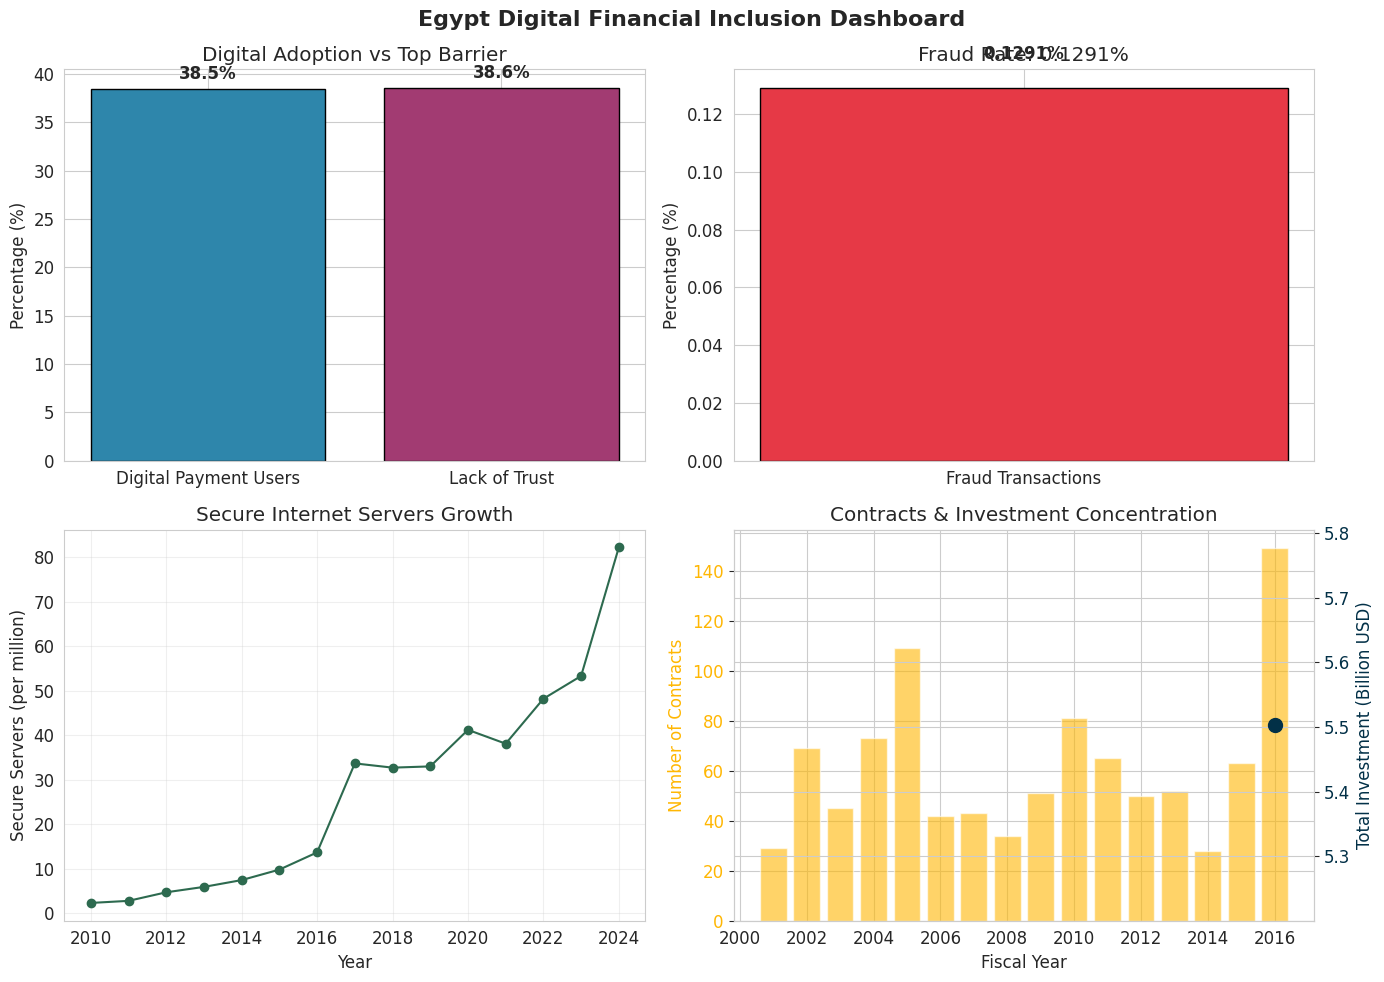

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Egypt Digital Financial Inclusion Dashboard', fontsize=16, fontweight='bold')

# 1. Digital adoption vs Trust barrier
ax = axes[0,0]
categories = ['Digital Payment Users', 'Lack of Trust']
values = [usage_rate, top_pct]
colors = ['#2E86AB', '#A23B72']
bars = ax.bar(categories, values, color=colors, edgecolor='black')
ax.set_ylabel('Percentage (%)')
ax.set_title('Digital Adoption vs Top Barrier')
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

# 2. Fraud overview
ax = axes[0,1]
ax.bar(['Fraud Transactions'], [fraud_pct], color='#E63946', edgecolor='black')
ax.set_ylabel('Percentage (%)')
ax.set_title(f'Fraud Rate: {fraud_pct:.4f}%')
ax.text(0, fraud_pct+0.01, f'{fraud_pct:.4f}%', ha='center', fontweight='bold')

# 3. Secure servers growth over time (line)
ax = axes[1,0]
years = [int(y) for y in year_cols if not pd.isna(df_egypt_servers[y].values[0])]
servers_vals = [float(df_egypt_servers[str(y)].values[0]) for y in years]
ax.plot(years, servers_vals, marker='o', linestyle='-', color='#2D6A4F')
ax.set_xlabel('Year')
ax.set_ylabel('Secure Servers (per million)')
ax.set_title('Secure Internet Servers Growth')
ax.grid(True, alpha=0.3)

# 4. Contracts & GDP combined (dual axis)
ax = axes[1,1]
ax2 = ax.twinx()
# Contracts per year
ax.bar(yearly_contracts.index, yearly_contracts.values, alpha=0.6, color='#FFB703', label='Contracts')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Number of Contracts', color='#FFB703')
ax.tick_params(axis='y', labelcolor='#FFB703')
# GDP trend (if we had time series, use GDP values, but we only have quarters; for simplicity show investment)
ax2.plot([peak_year], [total_investment/1e9], 'o', color='#023047', markersize=10)
ax2.set_ylabel('Total Investment (Billion USD)', color='#023047')
ax2.tick_params(axis='y', labelcolor='#023047')
ax.set_title('Contracts & Investment Concentration')

plt.tight_layout()
plt.show()

Cell 10: Correlation Heatmap of Key Indicators

/tmp/ipykernel_2263/2106650860.py:30: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  servers_series = pd.Series(servers_by_year).fillna(method='ffill').fillna(method='bfill')


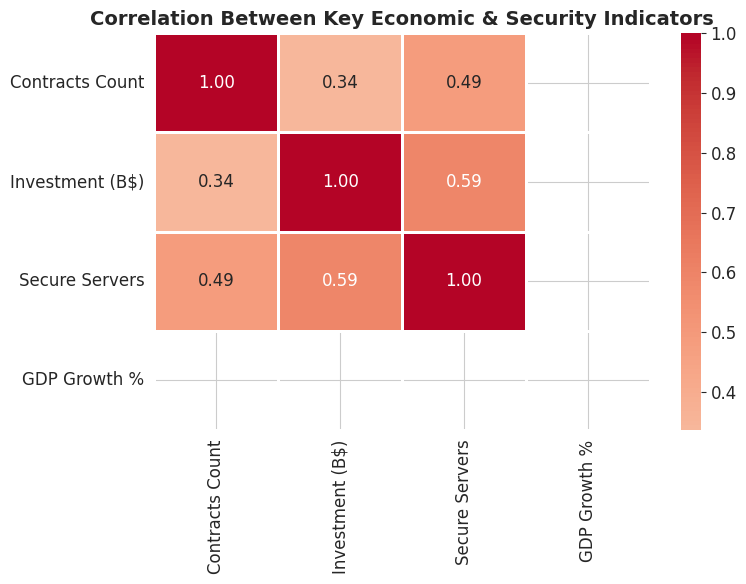

In [30]:
# Create a small dataframe of aggregated metrics for correlation
metrics_df = pd.DataFrame({
    'Digital Adoption %': [usage_rate],
    'Lack of Trust %': [top_pct],
    'Fraud Rate %': [fraud_pct],
    'Secure Servers': [latest_servers],
    'Total Investment (B$)': [total_investment/1e9],
    'GDP (Billion LE)': [latest_gdp/1000]
})

# For correlation we need multiple observations; we can use time series from servers & contracts
# Build a time-aligned dataframe (years 2001-2016)
years_range = range(2001, 2017)
contract_counts = [yearly_contracts.get(y,0) for y in years_range]
investment_by_year = df_egypt_contracts.groupby('Fiscal Year')['Supplier Contract Amount (US$)'].sum()
investment_vals = [investment_by_year.get(y,0)/1e9 for y in years_range]

# Approximate GDP growth (average)
gdp_vals = [avg_gdp_growth] * len(years_range)

# Servers data: interpolate or use available years
servers_by_year = []
for y in years_range:
    if y in years:
        idx = years.index(y)
        servers_by_year.append(servers_vals[idx])
    else:
        servers_by_year.append(np.nan)
# Forward fill
servers_series = pd.Series(servers_by_year).fillna(method='ffill').fillna(method='bfill')

time_df = pd.DataFrame({
    'Year': years_range,
    'Contracts Count': contract_counts,
    'Investment (B$)': investment_vals,
    'Secure Servers': servers_series,
    'GDP Growth %': gdp_vals
})

corr = time_df[['Contracts Count', 'Investment (B$)', 'Secure Servers', 'GDP Growth %']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=1)
plt.title('Correlation Between Key Economic & Security Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Cell 11: Final Summary Table

In [31]:
summary = pd.DataFrame({
    'Metric': [
        'Digital Payment Usage', 'Top Barrier', 'Fraud Rate', 'Avg Fraud Amount',
        'Secure Servers (2024)', 'Total Investment (Contracts)', 'Total Contracts',
        'Peak Investment Year', 'Latest GDP (Million LE)', 'Avg GDP Quarterly Growth'
    ],
    'Value': [
        f'{usage_rate:.1f}%', f'{top_barrier} ({top_pct:.1f}%)',
        f'{fraud_pct:.4f}%', f'${avg_fraud_amount:,.0f}',
        f'{latest_servers:.0f}', f'${total_investment/1e9:.1f}B',
        f'{num_contracts:,}', f'{peak_year} ({peak_count} contracts)',
        f'{latest_gdp:,.0f}', f'{avg_gdp_growth:.2f}%'
    ]
})

print("\n" + "="*60)
print("📊 FINAL INTEGRATION SUMMARY")
print("="*60)
print(summary.to_string(index=False))


📊 FINAL INTEGRATION SUMMARY
                      Metric                 Value
       Digital Payment Usage                 38.5%
                 Top Barrier Lack of trust (38.6%)
                  Fraud Rate               0.1291%
            Avg Fraud Amount            $1,467,967
       Secure Servers (2024)                    82
Total Investment (Contracts)                 $5.5B
             Total Contracts                   983
        Peak Investment Year  2016 (149 contracts)
     Latest GDP (Million LE)               182,324
    Avg GDP Quarterly Growth                14.16%


Cell 12: Recommendations

In [32]:
print("\n" + "="*60)
print("🎯 RECOMMENDATIONS FOR POLICYMAKERS")
print("="*60)

print("""
1. TRUST DEFICIT:
   → Launch national cybersecurity awareness campaigns
   → Emphasize fraud protection mechanisms in digital platforms

2. INFRASTRUCTURE GAP:
   → Expand secure servers at 15-20% annual growth
   → Prioritize rural areas and remote account opening

3. FRAUD DETECTION:
   → Flag all CASH_OUT and TRANSFER transactions above $1M
   → Implement real-time monitoring for accounts drained to zero

4. INVESTMENT ALIGNMENT:
   → Sustain high investment levels (peak 2016 as benchmark)
   → Link digital projects to economic growth cycles
""")

print("\n✅ Integration dashboard complete. Ready for submission.")


🎯 RECOMMENDATIONS FOR POLICYMAKERS

1. TRUST DEFICIT:
   → Launch national cybersecurity awareness campaigns
   → Emphasize fraud protection mechanisms in digital platforms

2. INFRASTRUCTURE GAP:
   → Expand secure servers at 15-20% annual growth
   → Prioritize rural areas and remote account opening

3. FRAUD DETECTION:
   → Flag all CASH_OUT and TRANSFER transactions above $1M
   → Implement real-time monitoring for accounts drained to zero

4. INVESTMENT ALIGNMENT:
   → Sustain high investment levels (peak 2016 as benchmark)
   → Link digital projects to economic growth cycles


✅ Integration dashboard complete. Ready for submission.
